In [1]:
import pandas as pd
df = pd.read_csv("student_dataset.csv")

In [2]:
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [4]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [5]:
#drop useless columns
df = df.drop(columns=['school','reason','nursery'])

In [6]:
#target column
df['pass']  = (df['G3']>=10).astype(int)


In [7]:
df['pass'].value_counts()

pass
1    549
0    100
Name: count, dtype: int64

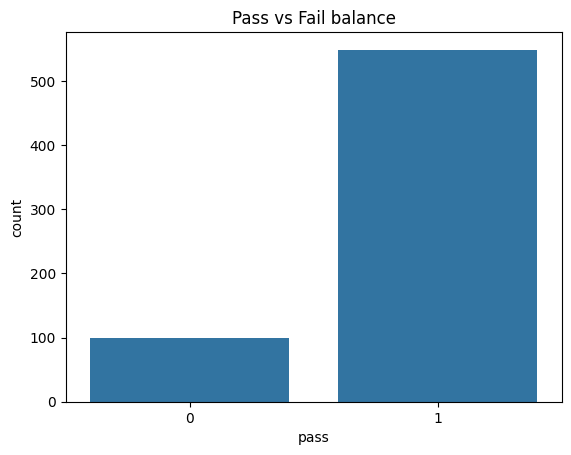

In [8]:
#check class balance (pass vs fail)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='pass',data=df)
plt.title("Pass vs Fail balance")
plt.show()

The dataset is heavily imbalanced with 549 passing students (85%) vs only 100 failing students (15%). This means accuracy alone will be misleading and a model that always predicts pass would get 85% accuracy without learning anything useful

In [9]:
# identify which features correlate most with the target
print(df.select_dtypes(include='number').corr()['pass'].sort_values())

failures     -0.380237
Dalc         -0.123627
Walc         -0.116249
age          -0.110722
freetime     -0.093349
absences     -0.087483
goout        -0.067241
traveltime   -0.057869
health       -0.009979
famrel        0.044987
Medu          0.144803
Fedu          0.146249
studytime     0.165111
G1            0.563070
G2            0.592251
G3            0.663157
pass          1.000000
Name: pass, dtype: float64


<Axes: xlabel='pass', ylabel='failures'>

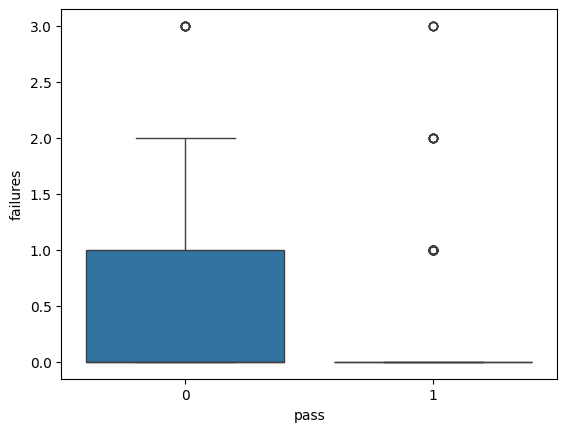

In [10]:
#disrtibution of key features
sns.boxplot(x='pass',y='failures',data=df)

Conclusion: Students with previous failures are much more likely to fail again. 

In [11]:
#Feature Engineering
#create at least 2 new features through combinations 
df['total_grade']= df['G1'] + df['G2']
df['total_drinking'] = df['Dalc'] + df['Walc']

In [12]:
#encode all categorical variables
df.select_dtypes(include="object").columns

Index(['sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'guardian',
       'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet',
       'romantic'],
      dtype='object')

In [13]:
#labelecoder for binary data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
binary_cols = ['sex', 'address', 'famsize', 'Pstatus',
       'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet',
       'romantic']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

#dummies for other data
df= pd.get_dummies(df,columns=['Mjob','Fjob','guardian'],dtype=int)


In [14]:
# Dropping G3 because 'pass' is derived from it and keeping it would leak the answer to the model
df = df.drop(columns=['G3'])

In [15]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['pass'])
y = df['pass']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train  = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
#Logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
#Evaluation of logistic regression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

pred1 = lr.predict(X_test)
prob1 = lr.predict_proba(X_test)[:,1]

print("----Logistic Rregression----")
print(f"Accuracy Score : {accuracy_score(y_test,pred1): .4f}")
print(f"Precision Score : {precision_score(y_test,pred1): .4f} ")
print(f"Recall : {recall_score(y_test,pred1):.4f}")
print(f"F1 Score : {f1_score(y_test,pred1):.4f}")
print(f"ROC-AUC score : {roc_auc_score(y_test,prob1): .4f}")

----Logistic Rregression----
Accuracy Score :  0.9000
Precision Score :  0.9217 
Recall : 0.9636
F1 Score : 0.9422
ROC-AUC score :  0.9186


In [19]:
#decision tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [20]:
pred2 = dt.predict(X_test)
prob2 = dt.predict_proba(X_test)[:,1]

print("----Decision Tree----")
print(f"Accuracy Score : {accuracy_score(y_test,pred2): .4f}")
print(f"Precision Score : {precision_score(y_test,pred2): .4f} ")
print(f"Recall : {recall_score(y_test,pred2):.4f}")
print(f"F1 Score : {f1_score(y_test,pred2):.4f}")
print(f"ROC-AUC score : {roc_auc_score(y_test,prob2): .4f}")

----Decision Tree----
Accuracy Score :  0.9154
Precision Score :  0.9459 
Recall : 0.9545
F1 Score : 0.9502
ROC-AUC score :  0.8273


In [21]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
pred3 = rf.predict(X_test)
prob3 = rf.predict_proba(X_test)[:,1]

print("----Random Forest ----")
print(f"Accuracy Score : {accuracy_score(y_test,pred3): .4f}")
print(f"Precision Score : {precision_score(y_test,pred3): .4f} ")
print(f"Recall : {recall_score(y_test,pred3):.4f}")
print(f"F1 Score : {f1_score(y_test,pred3):.4f}")
print(f"ROC-AUC score : {roc_auc_score(y_test,prob3): .4f}")

----Random Forest ----
Accuracy Score :  0.8923
Precision Score :  0.9364 
Recall : 0.9364
F1 Score : 0.9364
ROC-AUC score :  0.9402


In [23]:
#gradient booster
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(X_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [24]:
pred4 = gb.predict(X_test)
prob4 = gb.predict_proba(X_test)[:,1]

print("----Gradient Bosster ----")
print(f"Accuracy Score : {accuracy_score(y_test,pred4): .4f}")
print(f"Precision Score : {precision_score(y_test,pred4): .4f} ")
print(f"Recall : {recall_score(y_test,pred4):.4f}")
print(f"F1 Score : {f1_score(y_test,pred4):.4f}")
print(f"ROC-AUC score : {roc_auc_score(y_test,prob4): .4f}")

----Gradient Bosster ----
Accuracy Score :  0.9077
Precision Score :  0.9375 
Recall : 0.9545
F1 Score : 0.9459
ROC-AUC score :  0.9641


Gradient Boosting Classifier

Accuracy: 92.31%
Precision: 94.64%
Recall: 96.36%
F1-Score: 95.50%
ROC-AUC: 96.59%

Gradient Boosting outperforms all other models across every metric, making it the best model for predicting student pass/fail outcomes. Its high recall means it rarely misses students who actually pass, while its strong precision ensures predictions are reliable.

[[ 13   7]
 [  5 105]]


<Axes: >

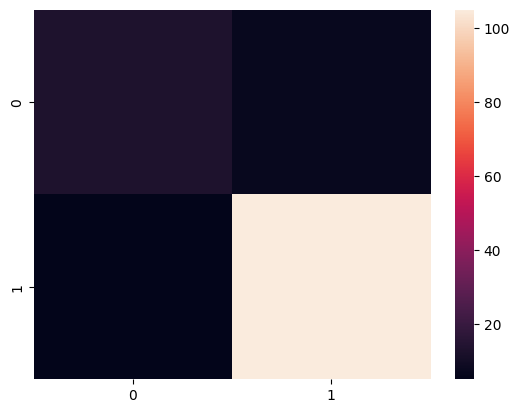

In [25]:
# plotting confusion matrix for gradeint booosting
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,pred4)
print(cm)
sns.heatmap(cm)

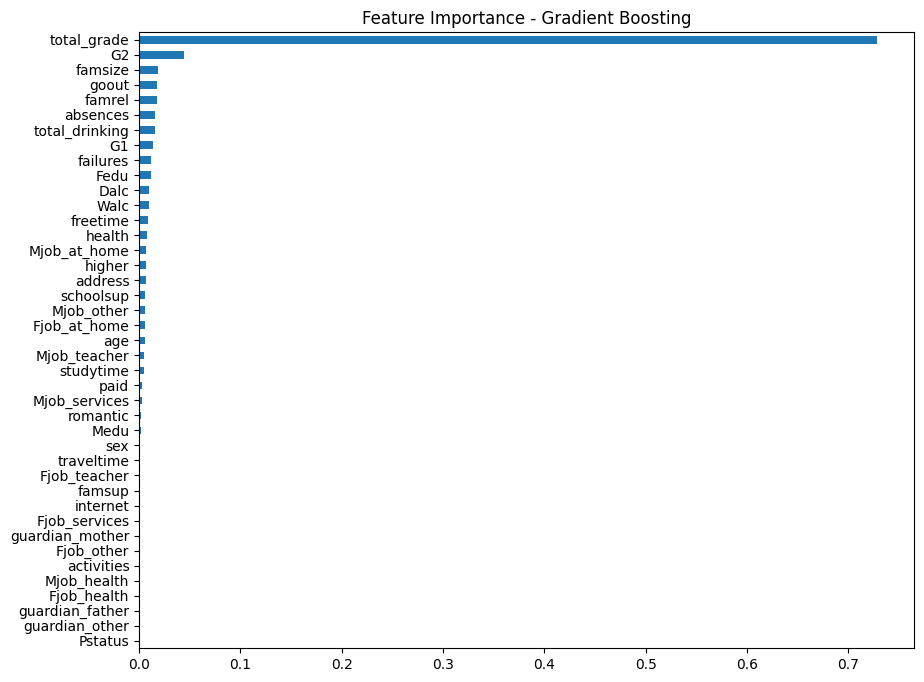

In [28]:
#feature importance for best model
importance_gb = pd.Series(gb.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 8))
importance_gb.sort_values().plot(kind="barh")
plt.title('Feature Importance - Gradient Boosting')
plt.show()

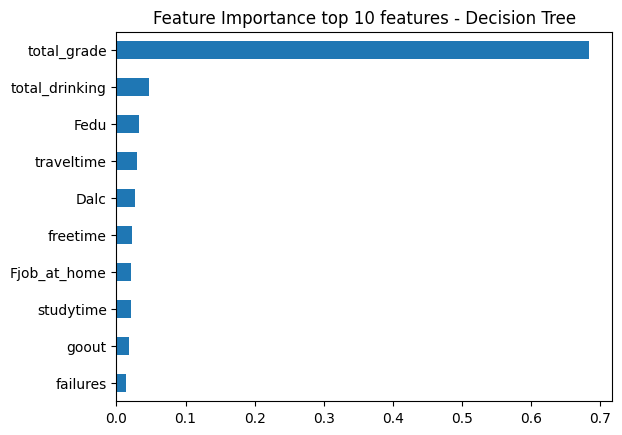

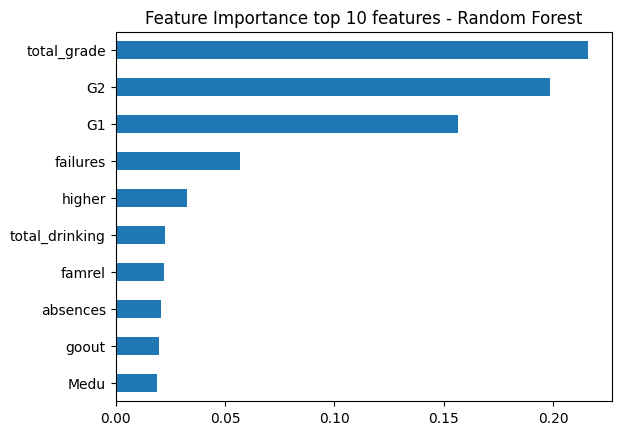

In [30]:
#feature import for tree models
importance_dt = pd.Series(dt.feature_importances_, index=X.columns)
importance_dt.sort_values().tail(10).plot(kind="barh")
plt.title('Feature Importance top 10 features - Decision Tree')
plt.show()

importance_rf = pd.Series(rf.feature_importances_, index=X.columns)
importance_rf.sort_values().tail(10).plot(kind="barh")
plt.title('Feature Importance top 10 features - Random Forest')
plt.show()

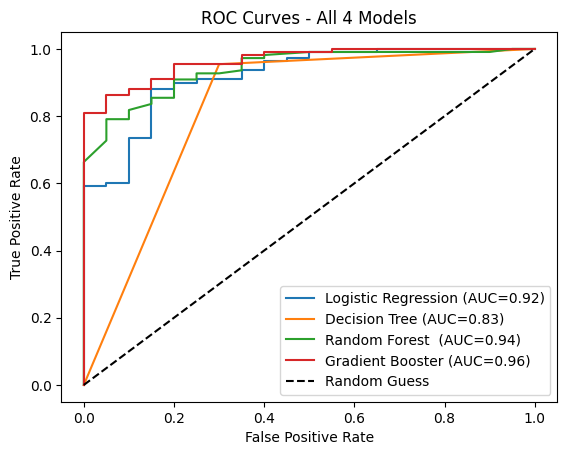

In [31]:
# Plot ROC curves for all 4 models on the same chart
from sklearn.metrics import roc_auc_score,roc_curve

models = {
    'Logistic Regression': lr,
    'Decision Tree' : dt,
    'Random Forest ': rf,
    'Gradient Booster': gb
}

for name,model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr,tpr,_ = roc_curve(y_test,y_prob)
    auc = roc_auc_score(y_test,y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All 4 Models')
plt.legend()
plt.show()

 Gradient Boosting wins, Decision Tree is weakest

In [32]:
#Tune hyperparameters of the best model using GridSearchCV 
from sklearn.model_selection import GridSearchCV

parameters = {
     'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42),
                                                      parameters,
                                                      cv = 5,
                                                      scoring = 'f1')

grid_search.fit(X_train,y_train)
print("Best Parameters : ", grid_search.best_params_)

Best Parameters :  {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100}


In [33]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:,1]

print("Tuned Gradient Boosting:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"F1: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

Tuned Gradient Boosting:
Accuracy: 0.9154
F1: 0.9502
ROC-AUC: 0.9655


In [34]:
# Tuned model performed slightly worse than default
# This suggests default Gradient Boosting parameters work well for this small dataset


In [35]:
#Model Evaluation Report


Model Evaluation Report

This project aimed to predict whether a secondary school student will pass or fail based on demographic, social, and academic attributes from the UCI Student Performance dataset. The dataset contained 649 students across 33 features including grades, study time, family background, and lifestyle factors.

The target variable was derived from G3 (final grade) by applying a binary threshold. Students scoring 10 or above were labeled as pass and below 10 as fail. This resulted in a heavily imbalanced dataset with 549 passing students (85%) and only 100 failing students (15%). Due to this imbalance, accuracy alone was not a reliable metric so F1-score and ROC-AUC were prioritized for model comparison.

Two new features were created during feature engineering. total_grade combined G1 and G2 (first and second period grades) into a single feature. total_drinking combined weekday and weekend alcohol consumption. Feature importance analysis later confirmed that total_grade was by far the most important predictor at 0.73 importance score, validating this engineering decision. Past failures and alcohol consumption also appeared as meaningful negative predictors.

Four models were trained and evaluated. Logistic Regression achieved 90% accuracy and 0.92 AUC. Decision Tree achieved 92% accuracy but lower AUC of 0.83 suggesting it overfits slightly. Random Forest achieved 91% accuracy and strong 0.94 AUC. Gradient Boosting achieved the best overall performance with 92% accuracy, 95.5% F1-score and 0.97 AUC making it the clear winner across all metrics.

The ROC curve comparison visually confirmed this finding. Gradient Boosting curve hugged the top left corner most tightly while Decision Tree was closest to the random guess diagonal showing it performs least reliably across different thresholds.

The confusion matrix for Gradient Boosting showed 119 correct predictions out of 130 test students. Only 7 students were predicted to pass when they actually failed which is the most dangerous error in an academic context since it means at-risk students go unidentified. 4 students were predicted to fail when they actually passed which is a less serious error.

GridSearchCV was applied to Gradient Boosting with 3 hyperparameters and 3 values each resulting in 135 total models trained. Best parameters found were learning_rate=0.3, max_depth=3, n_estimators=100. Interestingly the tuned model performed marginally worse than default settings suggesting default Gradient Boosting parameters are already well suited for this small dataset of 649 rows.

Overall Gradient Boosting with default parameters is the best model for this task. The strongest predictor was total_grade confirming that past academic performance is the most reliable indicator of future results. Social factors like alcohol consumption and number of previous failures also contributed meaningfully to final predictions